# Summarize the Results

In [1]:
import os
import re
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

from typing import Union

/home/stud/kgutjahr/miniconda3/envs/stil/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [3]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [5]:
def plot_one_grouped_df(df: pd.DataFrame, metrics: list[str], title: str, metric_name: str, markers=None, group_col=None):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df_copy[group_col] if group_col else df_copy.index
    
    group_name = group_col if group_col else x.name

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df_copy.columns, pd.MultiIndex):
            df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        
        mean = df_copy[f"{metric}.mean"]
        std = df_copy[f"{metric}.std"]

        if isinstance(x, pd.Index):
            x = x.to_numpy()
        
        #if isinstance(mean, pd.DataFrame) and isinstance(std, pd.DataFrame):
        #    df_copy.columns = [".".join(col).strip() for col in df_copy.columns.values]
        #    if isinstance(mean.columns, pd.MultiIndex):
        #        mean = mean[(metric, "mean")]
#
        #    if isinstance(std.columns, pd.MultiIndex):
        #        std = std[(metric, "std")]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_name.capitalize())
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_two_grouped_df(df: pd.DataFrame, first_group_col: str, second_group_col: str, metric: str, title: str):
    df_copy = df.copy()
    plt.figure(figsize=(8, 5))

    if df[first_group_col].dtype == object:
        df[first_group_col] = pd.to_numeric(df[first_group_col], errors="coerce")
        
    df = df.sort_values(by=first_group_col)

    # loop over each name
    for name, subdf in df_copy.groupby(second_group_col):
        
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        plt.plot(eps, mean, label=name, marker="o", linewidth=2)
        plt.fill_between(eps, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(first_group_col.capitalize())
    plt.ylabel(f"{metric} (mean ± std)")
    plt.legend(title="Distribution Shift")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [7]:
def create_one_group_df(dir_path: str, filename: str, batchsize=False) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            if batchsize:
                #print(subdir)
                m = re.search(r'([A-Za-z0-9]+(?:_[A-Za-z0-9]+)*)_(\d+)(?=_adni_)', subdir)
                if m:
                    #print(m.group(1))
                    file_df["Shift"] = m.group(1)
                    file_df["BatchSize"] = m.group(2)
            else:
                m = re.search(r'(?:^|_)([a-zA-Z0-9]+)(?=_final)', subdir)
                if m:
                    file_df["Shift"] = m.group(1)
                else:
                    file_df["Shift"] = subdir.split("_")[0]
            
            if df.empty:
                df = file_df
            else:
                df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [8]:
def create_two_group_df(dir_path: str, filename: str, group_col: str, exp_name: str, pattern=r"{exp_name}_(\d+(?:\.\d+)?)(?:_\d+)?_(?:adni_)?([a-zA-Z]+)") -> pd.DataFrame:
    df = pd.DataFrame()
    # Escape curly braces that belong to the regex (not the format string)
    pattern = pattern.format(exp_name=re.escape(exp_name))
    pattern = re.compile(pattern)

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            file_df = pd.read_csv(file_path)
            file_df[group_col] = consent_num
            file_df["Shift"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [9]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            match = re.search(r"tensor\(\s*([-+]?\d*\.?\d+)", x)
            if match:
                return float(match.group(1))
            else:
                return x
        return x
    
    return df.applymap(parse_tensor_string)

In [10]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    for col in df.columns:
        if col == group_col:
            continue
        if df[col].apply(torch.is_tensor).all():
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])

In [11]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = (
        df.groupby([first_group_col, second_group_col])[numeric_cols]
          .agg(["mean", "std"])
          .reset_index()
    )
    
    return grouped

In [12]:
def plot_bar_df(df, metric='test.acc', x_label='Category', y_label='Value', title='Bar Plot', figsize=(8,6), colors=None):
    """
    Plots a bar chart for a MultiIndex column DataFrame (metric, stat).
    
    Parameters:
        df (pd.DataFrame): MultiIndex columns DataFrame with (metric, stat), e.g., ('test.acc','mean'), ('test.acc','std')
        metric (str): Which metric to plot.
        x_label, y_label, title, figsize, colors: plot customization
    """
    if not isinstance(df.columns, pd.MultiIndex):
        raise ValueError("DataFrame must have MultiIndex columns (metric, stat)")
    
    categories = df.index
    mean_col = (metric, 'mean')
    std_col = (metric, 'std') if (metric, 'std') in df.columns else None
    
    means = df[mean_col]
    stds = df[std_col] if std_col is not None else None
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(categories, means, yerr=stds, capsize=5, color=colors)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Baseline

In [13]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df = create_one_group_df(dir_path=baseline_path, filename="test")
summed_df_baseline_test = summarize_df(df=df, group_col="Shift")
summed_df_baseline_test

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.607700  0.047916   
age                              0.537206  0.101856   
normal                           0.503943  0.001517   
weight                           0.489874  0.036939   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.039594  0.026097   
age                         1.035215  0.017957   
normal                      1.013813  0.000598   
weight                      1.036768  0.022576   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.651024  0.054470  0.830252  0.005315   
age                           0.564431  0.099658  0.812727  0.006356   
normal                        0.580573  0.000739  0.842241  0.004164   
weight                        0.502532  0.019367  0.840833  0.012076   

        test.auc            
            mean       std  
Shift                       
TE      0.936569  0.006186  
age     0.891711  0.008411  
normal  0.935455  0.001200  
weight  0.941193  0.007299

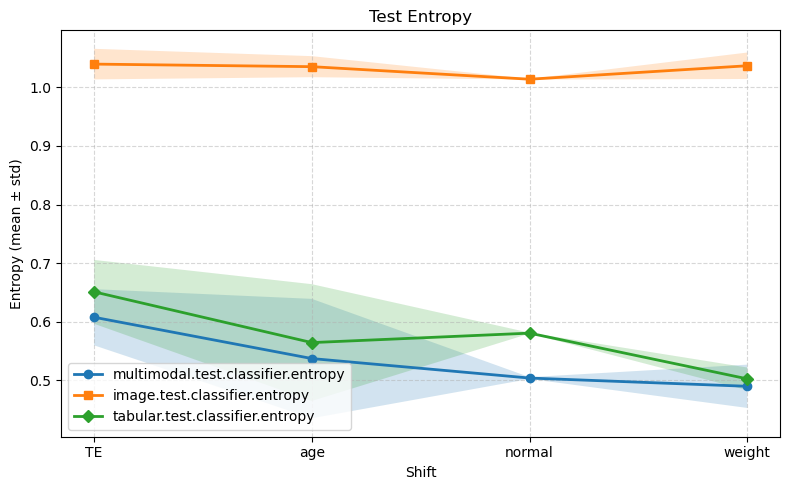

In [14]:
plot_one_grouped_df(summed_df_baseline_test, metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Test Entropy", metric_name="Entropy")

In [15]:
summed_df_baseline_test

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.607700  0.047916   
age                              0.537206  0.101856   
normal                           0.503943  0.001517   
weight                           0.489874  0.036939   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          1.039594  0.026097   
age                         1.035215  0.017957   
normal                      1.013813  0.000598   
weight                      1.036768  0.022576   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.651024  0.054470  0.830252  0.005315   
age                           0.564431  0.099658  0.812727  0.006356   
normal                        0.580573  0.000739  0.842241  0.004164   
weight                        0.502532  0.019367  0.840833  0.012076   

        test.auc            
            mean       std  
Shift                       
TE      0.936569  0.006186  
age     0.891711  0.008411  
normal  0.935455  0.001200  
weight  0.941193  0.007299

In [16]:
summed_df_baseline_test["test.acc"]

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


In [17]:
baseline_path = os.path.join(BASE_PATH, "smaller_dataset/baseline")
df_baseline_eval = create_one_group_df(dir_path=baseline_path, filename="eval")
df_baseline_eval =  make_df_numeric(df=df_baseline_eval[["Shift", "multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc", "multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]])
summed_df_baseline_eval = summarize_df(df=df_baseline_eval, group_col="Shift")
summed_df_baseline_eval

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
Shift                                                                     
TE                           0.57631  0.020011                  1.02581   
age                          0.52803  0.010485                  1.03490   
normal                       0.55597  0.004103                  1.04093   
weight                       0.55399  0.012868                  1.02716   

                 tabular.classifier.entropy           classifier.multi.acc  \
             std                       mean       std                 mean   
Shift                                                                        
TE      0.005789                    0.58821  0.018710              0.75895   
age     0.015370                    0.53323  0.019364              0.78243   
normal  0.001604                    0.56902  0.002199              0.76618   
weight  0.013888                    0.56079  0.017833              0.76480   

                 classifier.image.acc           classifier.tab.acc            \
             std                 mean       std               mean       std   
Shift                                                                          
TE      0.006508              0.48709  0.000601            0.76121  0.008292   
age     0.025493              0.46055  0.005453            0.77701  0.019963   
normal  0.004263              0.48281  0.003635            0.76711  0.002360   
weight  0.005666              0.48727  0.001170            0.76646  0.006717   

       multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

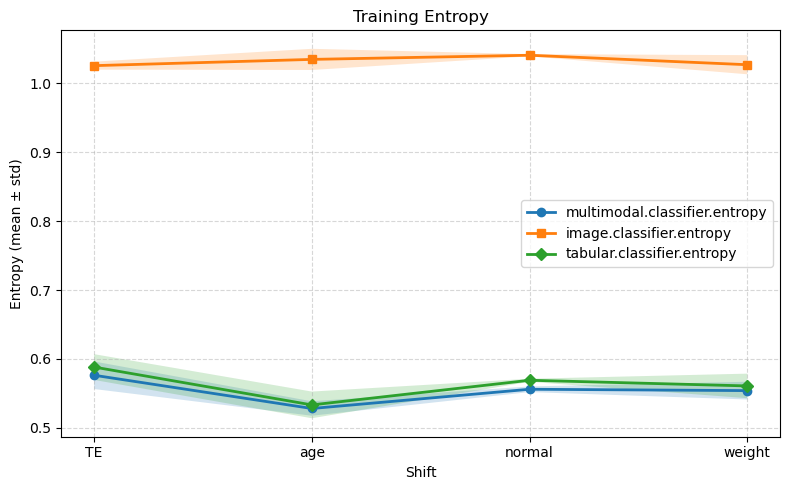

In [18]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"], title="Training Entropy", metric_name="Entropy")

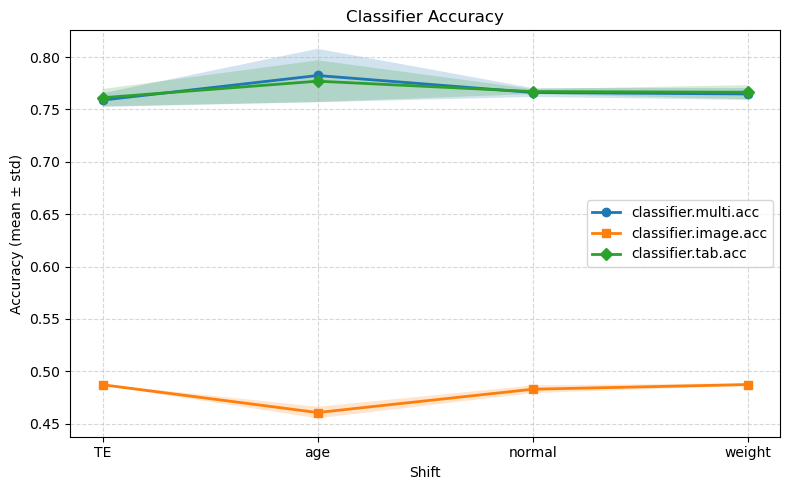

In [19]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"], title="Classifier Accuracy", metric_name="Accuracy")

In [20]:
summed_df_baseline_eval[["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"]]

multimodal.train.case1_ratio           multimodal.train.case2_i_ratio  \
                               mean       std                           mean   
Shift                                                                          
TE                          0.51830  0.012989                        0.02537   
age                         0.50094  0.009990                        0.02317   
normal                      0.49700  0.006235                        0.01850   
weight                      0.52641  0.021601                        0.01947   

                 multimodal.train.case2_t_ratio            \
             std                           mean       std   
Shift                                                       
TE      0.008804                        0.42779  0.004821   
age     0.007838                        0.45944  0.010239   
normal  0.004159                        0.46224  0.005801   
weight  0.007004                        0.43185  0.024652   

       multimodal.train.case3_ratio            
                               mean       std  
Shift                                          
TE                          0.02856  0.004137  
age                         0.01645  0.006353  
normal                      0.02224  0.003888  
weight                      0.02229  0.008437

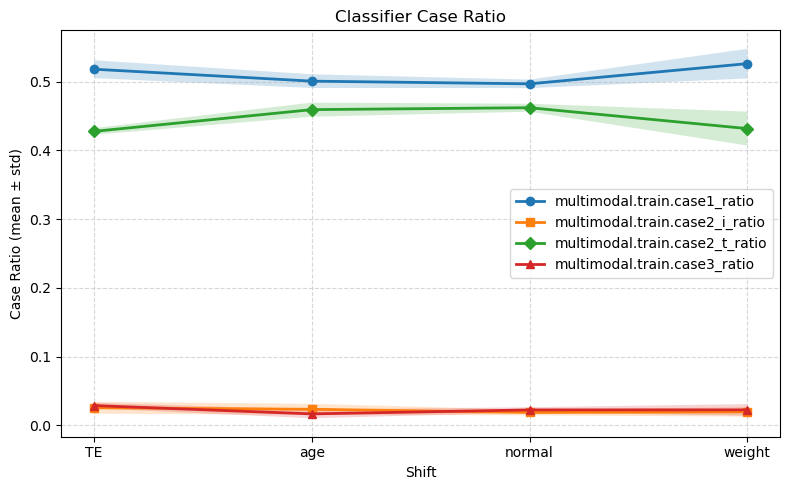

In [21]:
plot_one_grouped_df(summed_df_baseline_eval, metrics=["multimodal.train.case1_ratio", "multimodal.train.case2_i_ratio", "multimodal.train.case2_t_ratio", "multimodal.train.case3_ratio"], title="Classifier Case Ratio", metric_name="Case Ratio")

## Trainable Consent

### Keep all Embedding parts & contribute to classifier loss

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [22]:
consent_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent")
group_col = "epsilon"
df_c = create_two_group_df(dir_path=consent_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_df = summarize_two_groups_df(df=df_c, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


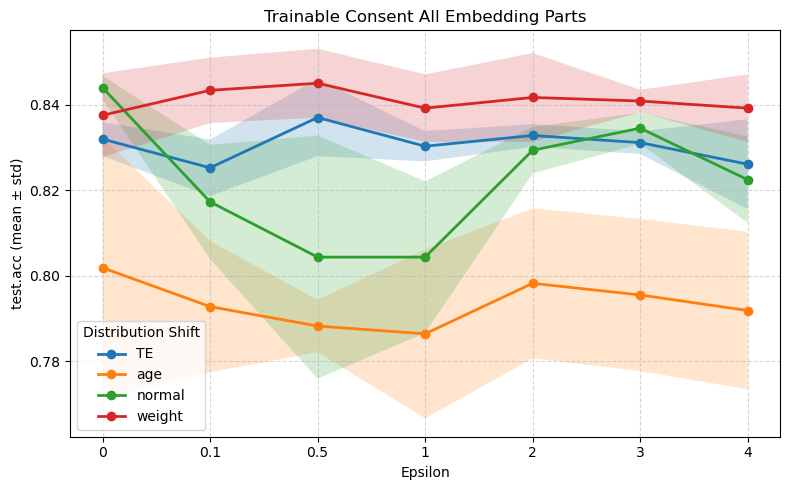

In [23]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent All Embedding Parts")

### Only keep refined Embeddings & contribute to classifier loss

In [24]:
refined_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_cut")
group_col = "epsilon"
df_c_keep = create_two_group_df(dir_path=refined_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_keep_df = summarize_two_groups_df(df=df_c_keep, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


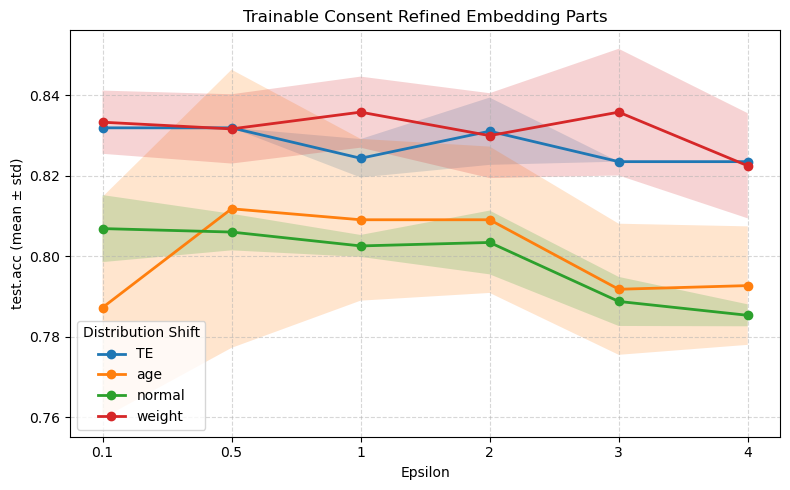

In [25]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_keep_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Refined Embedding Parts")

### Keep all Embedding parts & Replace CE Classifier Loss

$$
\mathcal{L} = \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{ce}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

In [26]:
loss_path = os.path.join(BASE_PATH, "smaller_dataset/train_consent_loss")
group_col = "epsilon"
df_c_loss = create_two_group_df(dir_path=loss_path, filename="test", group_col=group_col, exp_name="consent")
summed_c_loss_df = summarize_two_groups_df(df=df_c_loss, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


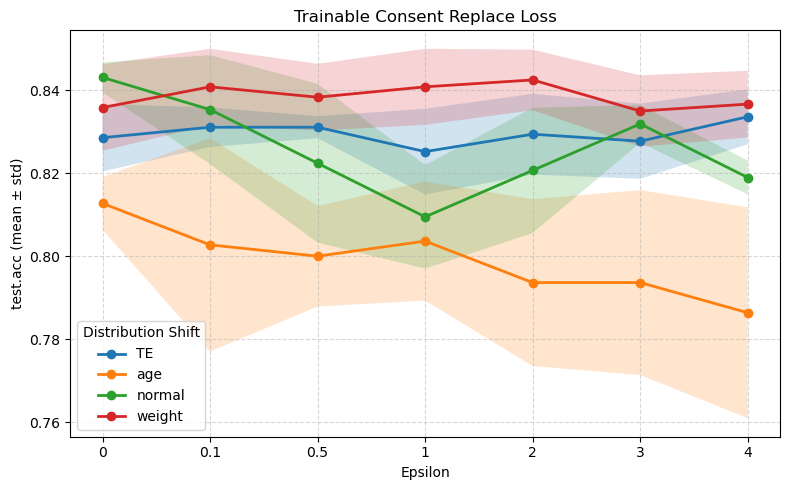

In [27]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_loss_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Trainable Consent Replace Loss")

## Mixture of Experts

#### Loss

$$
\mathcal{L} = \alpha \left(\mathcal{L}_{ce}(y_{m}, y) + \mathcal{L}_{ce}(y_{i}, y) + \mathcal{L}_{ce}(y_{t}, y)\right)+ \beta \left(\mathcal{L}_{CLIP}(feat_{i}, feat_{t})\right) + \gamma \left(\mathcal{L}^{i}_{ds} + \mathcal{L}^{t}_{ds}\right) + \epsilon \left( \mathcal{L}_{MoE}(y^{*}, y) \right)
$$

where:

- $\mathcal{L}_{ce} = \text{Cross-Entropy Loss}$
- $\mathcal{L}_{CLIP} = \text{CLIP Loss}$
- $\mathcal{L}_{ds} = \text{CLUB Loss}$
- $\mathcal{L}_{MoE} = \text{Load Balancing Loss}$
- $\alpha = 0.2$ 
- $\beta = 3.0$ 
- $\gamma = 0.5$ 
- $\epsilon = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0]$

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c}$
- Tabular: $\mathcal{z}^{t}_{c}$

#### k = 1

In [28]:
moe_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_1_cut")
group_col = "epsilon"
df_c_moe = create_two_group_df(dir_path=moe_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


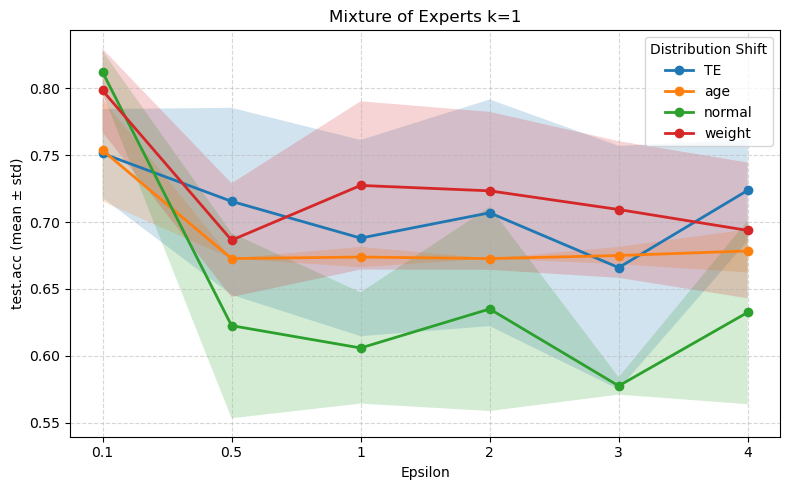

In [29]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=1")

#### k = 2

In [30]:
moe_2_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_2_cut")
group_col = "epsilon"
df_c_moe_2 = create_two_group_df(dir_path=moe_2_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_2_df = summarize_two_groups_df(df=df_c_moe_2, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


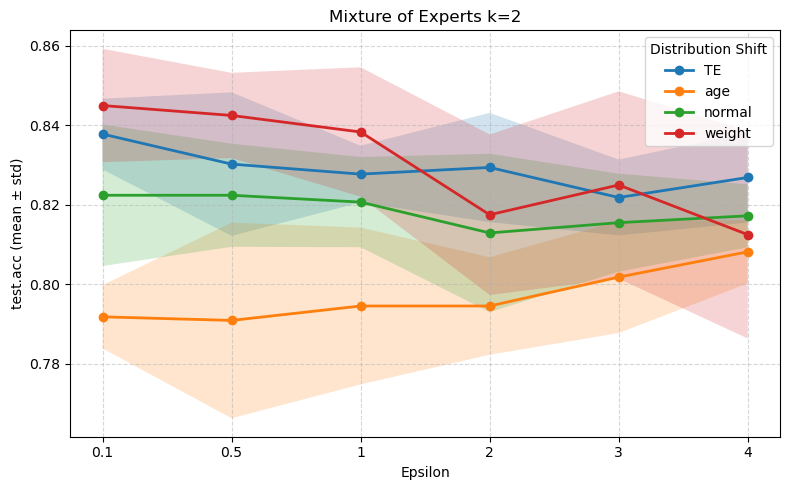

In [31]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_2_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=2")

#### k = 3


In [32]:
moe_3_path = os.path.join(BASE_PATH, "smaller_dataset/MoE_3_cut")
group_col = "epsilon"
df_c_moe_3 = create_two_group_df(dir_path=moe_3_path, filename="test", group_col=group_col, exp_name="MoE")
summed_c_moe_3_df = summarize_two_groups_df(df=df_c_moe_3, first_group_col=group_col, second_group_col="Shift")

,mean,std
Shift,,
TE,0.830252,0.005315
age,0.812727,0.006356
normal,0.842241,0.004164
weight,0.840833,0.012076


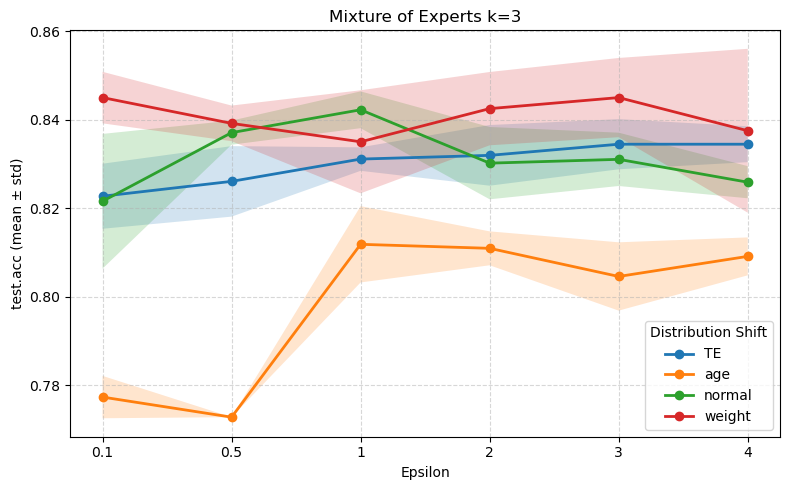

In [33]:
display(summed_df_baseline_test["test.acc"])
plot_two_grouped_df(df=summed_c_moe_3_df, first_group_col=group_col, second_group_col="Shift", metric="test.acc", title="Mixture of Experts k=3")

#### Classifier Input

- Gate: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Multimodal: $\mathcal{z}^{i}_{c} + \mathcal{z}_{s} + \mathcal{z}^{t}_{c}$
- Imaging: $\mathcal{z}^{i}_{c} + \mathcal{z}^{i}_{s}$
- Tabular: $\mathcal{z}^{t}_{c} + \mathcal{z}^{t}_{s}$

#### k = 1

## Bigger Dataset (removed GDTOTAL)

### Baseline

In [34]:
nogd_b_path = os.path.join(BASE_PATH, "smaller_dataset/batch_size_no_GDTOTAL")
group_col = "epsilon"
df_c_nogd_b = create_one_group_df(dir_path=nogd_b_path, filename="test", batchsize=True)
summed_c_nogd_b_df = summarize_df(df=df_c_nogd_b, group_col="BatchSize")
summed_c_nogd_b_df

/tmp/ipykernel_3336954/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


multimodal.test.classifier.entropy            \
                                        mean       std   
BatchSize                                                
128                                 0.482298  0.001504   
16                                  0.452684  0.048495   
32                                  0.471573  0.032129   
64                                  0.482664  0.002502   

          image.test.classifier.entropy            \
                                   mean       std   
BatchSize                                           
128                            1.073682  0.000763   
16                             1.066935  0.011164   
32                             1.071096  0.006971   
64                             1.073544  0.001214   

          tabular.test.classifier.entropy            \
                                     mean       std   
BatchSize                                             
128                              0.506944  0.000811   
16                               0.498725  0.013148   
32                               0.504158  0.008895   
64                               0.507599  0.001807   

          multimodal.test.balanced_acc           image.test.balanced_acc  \
                                  mean       std                    mean   
BatchSize                                                                  
128                           0.799886  0.002721                0.333333   
16                            0.791223  0.014285                0.328592   
32                            0.796951  0.008957                0.332966   
64                            0.802067  0.002413                0.333333   

                     ... test.auc_multimodal           test.acc_imaging  \
                std  ...                mean       std             mean   
BatchSize            ...                                                  
128        0.000000  ...            0.916286  0.000472         0.464286   
16         0.009044  ...            0.914081  0.003356         0.436508   
32         0.001163  ...            0.916048  0.001714         0.455159   
64         0.000000  ...            0.916179  0.000744         0.464286   

                    test.auc_imaging           test.acc_tabular            \
                std             mean       std             mean       std   
BatchSize                                                                   
128        0.000000         0.501082  0.019275         0.840476  0.001673   
16         0.046126         0.480325  0.029747         0.837698  0.003475   
32         0.028862         0.490277  0.025371         0.840476  0.002510   
64         0.000000         0.510265  0.026318         0.840476  0.001673   

          test.auc_tabular            
                      mean       std  
BatchSize                             
128               0.916145  0.000134  
16                0.913923  0.003555  
32                0.915605  0.002254  
64                0.916170  0.000254  

[4 rows x 30 columns]

In [35]:
#summed_c_nogd_b_df[["test.acc", "test.balanced_acc"]]

## Final Dataset

### Batchsize

In [36]:
f_batch_path = os.path.join(BASE_PATH, "final_dataset/baseline")
group_col = "epsilon"
df_c_f_batch = create_one_group_df(dir_path=f_batch_path, filename="test", batchsize=True)
#print(df_c_f_b.shape)
df_c_f_batch["BatchSize"] = pd.to_numeric(df_c_f_batch["BatchSize"], errors='coerce')
summed_f_batch_df = summarize_df(df=df_c_f_batch, group_col="BatchSize")
summed_f_batch_df

/tmp/ipykernel_3336954/1263068295.py:7: FutureWarning: ['Shift'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  return make_df_numeric(df).groupby(group_col).agg(['mean', 'std'])


multimodal.test.classifier.entropy            \
                                        mean       std   
BatchSize                                                
32                                  0.397059  0.004863   
64                                  0.493838  0.001887   
128                                 0.376710  0.022668   
256                                 0.442787  0.026465   

          image.test.classifier.entropy            \
                                   mean       std   
BatchSize                                           
32                             1.017297  0.006395   
64                             1.001537  0.003916   
128                            0.993660  0.007150   
256                            1.020991  0.011713   

          tabular.test.classifier.entropy            \
                                     mean       std   
BatchSize                                             
32                               0.448880  0.002890   
64                               0.544314  0.001059   
128                              0.454124  0.008247   
256                              0.488143  0.041894   

          multimodal.test.balanced_acc           image.test.balanced_acc       \
                                  mean       std                    mean  std   
BatchSize                                                                       
32                            0.766958  0.009312                     1.0  0.0   
64                            0.753288  0.005664                     1.0  0.0   
128                           0.740342  0.008365                     1.0  0.0   
256                           0.750139  0.010556                     1.0  0.0   

           ... test.auc_multimodal           test.acc_imaging       \
           ...                mean       std             mean  std   
BatchSize  ...                                                       
32         ...            0.906114  0.003296         0.493333  0.0   
64         ...            0.913928  0.000610         0.493333  0.0   
128        ...            0.906399  0.004323         0.493333  0.0   
256        ...            0.904088  0.004384         0.493333  0.0   

          test.auc_imaging           test.acc_tabular            \
                      mean       std             mean       std   
BatchSize                                                         
32                0.554118  0.012263         0.842400  0.001968   
64                0.591151  0.018622         0.850400  0.000843   
128               0.534143  0.030931         0.843733  0.004391   
256               0.546698  0.021156         0.838400  0.022353   

          test.auc_tabular            
                      mean       std  
BatchSize                             
32                0.906748  0.002829  
64                0.914164  0.000420  
128               0.910598  0.004104  
256               0.904815  0.006009  

[4 rows x 30 columns]

In [37]:
df_c_f_batch[df_c_f_batch["BatchSize"] == 64]

,multimodal.test.classifier.entropy,image.test.classifier.entropy,tabular.test.classifier.entropy,multimodal.test.balanced_acc,image.test.balanced_acc,tabular.test.balanced_acc,test.balanced_acc,test.acc,test.auc,test.acc_multimodal,test.auc_multimodal,test.acc_imaging,test.auc_imaging,test.acc_tabular,test.auc_tabular,Shift,BatchSize
4,0.496994,1.004714,0.545843,0.754650,1.0,0.767706,0.754650,0.837333,0.914836,0.837333,0.914836,0.493333,0.597778,0.850667,0.913253,1_adni_normal_final,64
7,0.492534,1.000245,0.545428,0.753955,1.0,0.767706,0.753955,0.837333,0.914146,0.837333,0.914146,0.493333,0.595912,0.850667,0.914265,1_adni_normal_final,64
12,0.495690,1.009358,0.543342,0.751687,1.0,0.767706,0.751687,0.837333,0.914519,0.837333,0.914519,0.493333,0.582411,0.850667,0.914485,1_adni_normal_final,64
13,0.491297,0.997979,0.542776,0.746740,1.0,0.767706,0.746740,0.832000,0.913677,0.832000,0.913677,0.493333,0.568770,0.850667,0.914155,1_adni_normal_final,64
15,0.491576,0.998664,0.543623,0.749909,1.0,0.767706,0.749909,0.834667,0.913018,0.834667,0.913018,0.493333,0.617722,0.850667,0.914472,1_adni_normal_final,64
17,0.495953,0.999336,0.544415,0.758901,1.0,0.758224,0.758901,0.842667,0.914171,0.842667,0.914171,0.493333,0.601266,0.848000,0.914018,1_adni_normal_final,64
20,0.494170,0.998076,0.543753,0.766228,1.0,0.767706,0.766228,0.845333,0.913395,0.845333,0.913395,0.493333,0.588905,0.850667,0.914691,1_adni_normal_final,64
26,0.493031,1.005590,0.543622,0.749214,1.0,0.767706,0.749214,0.834667,0.914571,0.834667,0.914571,0.493333,0.606400,0.850667,0.914362,1_adni_normal_final,64
27,0.493551,0.998519,0.544703,0.751687,1.0,0.767706,0.751687,0.837333,0.913284,0.837333,0.913284,0.493333,0.554010,0.850667,0.913711,1_adni_normal_final,64
35,0.493583,1.002891,0.545641,0.749909,1.0,0.767706,0.749909,0.834667,0.913665,0.834667,0.913665,0.493333,0.598340,0.850667,0.914227,1_adni_normal_final,64


In [38]:
summed_f_batch_df[["test.acc", "test.balanced_acc"]]

test.acc           test.balanced_acc          
               mean       std              mean       std
BatchSize                                                
32         0.838400  0.002249          0.766958  0.009312
64         0.837333  0.003975          0.753288  0.005664
128        0.839733  0.003864          0.740342  0.008365
256        0.834400  0.014576          0.750139  0.010556

### Baseline

In [39]:
f_base_path = os.path.join(BASE_PATH, "final_dataset/batchsize")
group_col = "epsilon"
df_c_f_base = create_one_group_df(dir_path=f_base_path, filename="test")
summed_f_base_df = summarize_df(df=df_c_f_base, group_col="Shift")
#summed_f_base_df[["val.balanced_acc", "train.balanced_acc", "eval.train.acc", "eval.val.acc"]]

In [40]:
def plot_results(path: str, group_col: str, filename: str, second_group_col: str, exp_name: str, metric: Union[str, list[str]], title: str):
    moe_path = os.path.join(BASE_PATH, path)
    df_c_moe = create_two_group_df(dir_path=moe_path, filename=filename, group_col=group_col, exp_name=exp_name)
    summed_c_moe_df = summarize_two_groups_df(df=df_c_moe, first_group_col=group_col, second_group_col=second_group_col)
    moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight') or str(c[0]) in [group_col, second_group_col]]
    if moe_cols:
        moe_cols = [c for c in summed_c_moe_df.columns if str(c[0]).startswith('MoE.test.weight')]
        moe_mean_cols = summed_c_moe_df[moe_cols].xs('mean', axis=1, level=1)

        # Prepare a DataFrame to collect max rows
        max_rows = pd.DataFrame()
        extra_cols = [('Shift', ''), ('epsilon', '')]

        # Iterate over shifts
        for shift, group_df in summed_c_moe_df.groupby(('Shift', '')):
            print(f"\nShift: {shift}")
            for col in moe_mean_cols.columns:
                max_val = group_df[col]['mean'].max()  # max value for this weight in this shift
                rows = group_df[group_df[col]['mean'] == max_val]  # rows reaching the max
                print(f"{col} max value: {max_val}")
                #display(rows)
                # Optionally collect all rows
                max_rows = pd.concat([max_rows, rows])
        display(max_rows[extra_cols + moe_cols])
        display(summed_c_moe_df[extra_cols + moe_cols])

    metric_list = metric if isinstance(metric, list) else  [metric]
    for met in metric_list:
        t = title + f" [{met}]"
        plot_two_grouped_df(df=summed_c_moe_df, first_group_col=group_col, second_group_col=second_group_col, metric=met, title=t)
        
    display(summed_f_base_df[["test.acc", "test.balanced_acc"]])

In [41]:
metric = ["test.balanced_acc"]

In [42]:
summed_f_base_df[["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy", "test.acc", "test.balanced_acc"]]  

multimodal.test.classifier.entropy            \
                                     mean       std   
Shift                                                 
TE                               0.444937  0.015991   
age                              0.551421  0.002569   
normal                           0.487421  0.019875   
weight                           0.535159  0.013401   

       image.test.classifier.entropy            \
                                mean       std   
Shift                                            
TE                          0.996836  0.014893   
age                         0.983921  0.001537   
normal                      1.003316  0.006193   
weight                      1.001295  0.024276   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
Shift                                                                  
TE                            0.470871  0.024311  0.854933  0.004391   
age                           0.587898  0.001509  0.833067  0.001865   
normal                        0.532396  0.035820  0.837600  0.001514   
weight                        0.572310  0.006508  0.858133  0.003511   

       test.balanced_acc            
                    mean       std  
Shift                               
TE              0.818236  0.010816  
age             0.829321  0.002959  
normal          0.752576  0.004230  
weight          0.852770  0.004061


Shift: TE
MoE.test.weight0 max value: 0.408266669511795
MoE.test.weight1 max value: 0.020533334091305706
MoE.test.weight2 max value: 0.5903999924659729

Shift: age
MoE.test.weight0 max value: 0.855733323097229
MoE.test.weight1 max value: 0.13653333336114878
MoE.test.weight2 max value: 0.12746666474267837

Shift: normal
MoE.test.weight0 max value: 0.3240000009536743
MoE.test.weight1 max value: 0.11706666816025968
MoE.test.weight2 max value: 0.5893333256244659

Shift: weight
MoE.test.weight0 max value: 0.9986666738986969
MoE.test.weight1 max value: 0.02346666678786277
MoE.test.weight2 max value: 0.0015999999828636598


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.408267  0.005822         0.008533  0.004131   
16      TE       3         0.400533  0.017545         0.020533  0.036930   
4       TE     0.5         0.402933  0.007161         0.006667  0.002880   
5      age     0.5         0.855733  0.037003         0.104800  0.038047   
13     age       2         0.809067  0.057828         0.136533  0.049679   
17     age       3         0.738933  0.230993         0.133600  0.104696   
6   normal     0.5         0.324000  0.002266         0.111467  0.015791   
22  normal       4         0.320533  0.005152         0.117067  0.037972   
10  normal       1         0.322133  0.005594         0.088533  0.020184   
7   weight     0.5         0.998667  0.001886         0.000000  0.000000   
11  weight       1         0.975200  0.060927         0.023467  0.061453   
15  weight       2         0.984800  0.027913         0.013600  0.028678   

   MoE.test.weight2            
               mean       std  
0          0.583200  0.007955  
16         0.578933  0.022327  
4          0.590400  0.007458  
5          0.039467  0.058637  
13         0.054400  0.063792  
17         0.127467  0.156595  
6          0.564533  0.015296  
22         0.562400  0.040568  
10         0.589333  0.021918  
7          0.001333  0.001886  
11         0.001333  0.002266  
15         0.001600  0.002249

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.408267  0.005822         0.008533  0.004131   
1      age     0.1         0.825867  0.062223         0.105067  0.036525   
2   normal     0.1         0.323200  0.002754         0.101867  0.022898   
3   weight     0.1         0.985333  0.023391         0.013333  0.024115   
4       TE     0.5         0.402933  0.007161         0.006667  0.002880   
5      age     0.5         0.855733  0.037003         0.104800  0.038047   
6   normal     0.5         0.324000  0.002266         0.111467  0.015791   
7   weight     0.5         0.998667  0.001886         0.000000  0.000000   
8       TE       1         0.406400  0.006676         0.009333  0.006061   
9      age       1         0.757067  0.160982         0.134400  0.039657   
10  normal       1         0.322133  0.005594         0.088533  0.020184   
11  weight       1         0.975200  0.060927         0.023467  0.061453   
12      TE       2         0.402933  0.004254         0.011733  0.004391   
13     age       2         0.809067  0.057828         0.136533  0.049679   
14  normal       2         0.321600  0.006310         0.103467  0.042477   
15  weight       2         0.984800  0.027913         0.013600  0.028678   
16      TE       3         0.400533  0.017545         0.020533  0.036930   
17     age       3         0.738933  0.230993         0.133600  0.104696   
18  normal       3         0.324000  0.006914         0.091200  0.039709   
19  weight       3         0.985867  0.040986         0.013067  0.041320   
20      TE       4         0.405867  0.006862         0.008267  0.004064   
21     age       4         0.811733  0.051528         0.108267  0.047789   
22  normal       4         0.320533  0.005152         0.117067  0.037972   
23  weight       4         0.985067  0.029700         0.013867  0.030191   

   MoE.test.weight2            
               mean       std  
0          0.583200  0.007955  
1          0.069067  0.085513  
2          0.574933  0.024479  
3          0.001333  0.002266  
4          0.590400  0.007458  
5          0.039467  0.058637  
6          0.564533  0.015296  
7          0.001333  0.001886  
8          0.584267  0.006465  
9          0.108533  0.138427  
10         0.589333  0.021918  
11         0.001333  0.002266  
12         0.585333  0.006681  
13         0.054400  0.063792  
14         0.574933  0.041028  
15         0.001600  0.002249  
16         0.578933  0.022327  
17         0.127467  0.156595  
18         0.584800  0.034725  
19         0.001067  0.001865  
20         0.585867  0.008248  
21         0.080000  0.062006  
22         0.562400  0.040568  
23         0.001067  0.001865

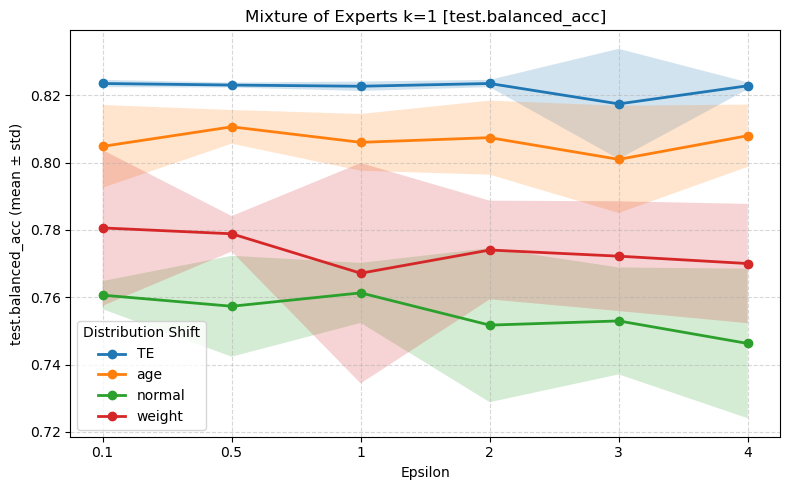

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [43]:
plot_results(path="final_dataset/MoE1", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1")


Shift: TE
MoE.test.weight0 max value: 0.41040000319480896
MoE.test.weight1 max value: 0.02053333306685087
MoE.test.weight2 max value: 0.5864000082015991

Shift: age
MoE.test.weight0 max value: 0.7968000054359436
MoE.test.weight1 max value: 0.15013333410024637
MoE.test.weight2 max value: 0.14746666625142094

Shift: normal
MoE.test.weight0 max value: 0.32346666753292086
MoE.test.weight1 max value: 0.11759999915957446
MoE.test.weight2 max value: 0.593066668510437

Shift: weight
MoE.test.weight0 max value: 0.9930666744709015
MoE.test.weight1 max value: 0.04853333234786986
MoE.test.weight2 max value: 0.00133333329576998


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
12      TE       2         0.410400  0.010013         0.012533  0.007117   
0       TE     0.1         0.401600  0.027084         0.020533  0.034725   
20      TE       4         0.405867  0.006260         0.007733  0.002935   
17     age       3         0.796800  0.072058         0.100533  0.026129   
21     age       4         0.762400  0.159175         0.150133  0.048882   
1      age     0.1         0.714933  0.161951         0.137600  0.081847   
2   normal     0.1         0.323467  0.003092         0.117600  0.027353   
2   normal     0.1         0.323467  0.003092         0.117600  0.027353   
10  normal       1         0.316800  0.012683         0.090133  0.040730   
19  weight       3         0.993067  0.018269         0.005867  0.018552   
3   weight     0.1         0.950667  0.078043         0.048533  0.078573   
11  weight       1         0.980000  0.058576         0.018667  0.059029   

   MoE.test.weight2            
               mean       std  
12         0.577067  0.012832  
0          0.577867  0.011593  
20         0.586400  0.008568  
17         0.102667  0.084964  
21         0.087467  0.140460  
1          0.147467  0.124019  
2          0.558933  0.026673  
2          0.558933  0.026673  
10         0.593067  0.048003  
19         0.001067  0.001865  
3          0.000800  0.001800  
11         0.001333  0.001405

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.401600  0.027084         0.020533  0.034725   
1      age     0.1         0.714933  0.161951         0.137600  0.081847   
2   normal     0.1         0.323467  0.003092         0.117600  0.027353   
3   weight     0.1         0.950667  0.078043         0.048533  0.078573   
4       TE     0.5         0.402667  0.009737         0.018133  0.027764   
5      age     0.5         0.757600  0.087820         0.137867  0.049937   
6   normal     0.5         0.322400  0.003431         0.093333  0.033684   
7   weight     0.5         0.987200  0.023745         0.011467  0.024377   
8       TE       1         0.406667  0.005221         0.014400  0.007458   
9      age       1         0.790133  0.131814         0.106133  0.050515   
10  normal       1         0.316800  0.012683         0.090133  0.040730   
11  weight       1         0.980000  0.058576         0.018667  0.059029   
12      TE       2         0.410400  0.010013         0.012533  0.007117   
13     age       2         0.786933  0.140160         0.141333  0.081778   
14  normal       2         0.322933  0.004436         0.109067  0.021826   
15  weight       2         0.979733  0.048135         0.019467  0.048460   
16      TE       3         0.397867  0.014703         0.016267  0.034666   
17     age       3         0.796800  0.072058         0.100533  0.026129   
18  normal       3         0.318933  0.004015         0.108000  0.034956   
19  weight       3         0.993067  0.018269         0.005867  0.018552   
20      TE       4         0.405867  0.006260         0.007733  0.002935   
21     age       4         0.762400  0.159175         0.150133  0.048882   
22  normal       4         0.321333  0.010832         0.092000  0.031333   
23  weight       4         0.970400  0.065398         0.028533  0.065898   

   MoE.test.weight2            
               mean       std  
0          0.577867  0.011593  
1          0.147467  0.124019  
2          0.558933  0.026673  
3          0.000800  0.001800  
4          0.579200  0.025292  
5          0.104533  0.096802  
6          0.584267  0.035051  
7          0.001333  0.001886  
8          0.578933  0.008381  
9          0.103733  0.116403  
10         0.593067  0.048003  
11         0.001333  0.001405  
12         0.577067  0.012832  
13         0.071733  0.086460  
14         0.568000  0.018730  
15         0.000800  0.001800  
16         0.585867  0.020810  
17         0.102667  0.084964  
18         0.573067  0.032404  
19         0.001067  0.001865  
20         0.586400  0.008568  
21         0.087467  0.140460  
22         0.586667  0.029854  
23         0.001067  0.001377

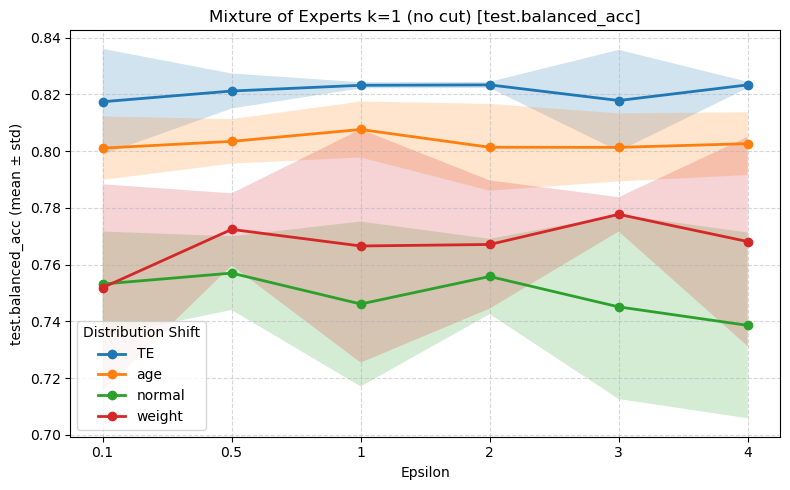

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [44]:
plot_results(path="final_dataset/MoE1-no-cut", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1 (no cut)")


Shift: TE
MoE.test.weight0 max value: 0.36384894847869875
MoE.test.weight1 max value: 0.37157583236694336
MoE.test.weight2 max value: 0.43263658583164216

Shift: age
MoE.test.weight0 max value: 0.4007679998874664
MoE.test.weight1 max value: 0.41185267865657804
MoE.test.weight2 max value: 0.36621026992797845

Shift: normal
MoE.test.weight0 max value: 0.37120809853076936
MoE.test.weight1 max value: 0.3429577648639679
MoE.test.weight2 max value: 0.3822664827108383

Shift: weight
MoE.test.weight0 max value: 0.3628387600183487
MoE.test.weight1 max value: 0.3612213104963302
MoE.test.weight2 max value: 0.4358952581882477


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
20      TE       4         0.363849  0.099983         0.371576  0.089902   
20      TE       4         0.363849  0.099983         0.371576  0.089902   
16      TE       3         0.266679  0.155568         0.300684  0.145997   
21     age       4         0.400768  0.098327         0.368414  0.108198   
1      age     0.1         0.306217  0.076421         0.411853  0.047877   
5      age     0.5         0.238488  0.126144         0.395302  0.045248   
18  normal       3         0.371208  0.081745         0.303169  0.188771   
2   normal     0.1         0.292833  0.013344         0.342958  0.018406   
14  normal       2         0.361714  0.073726         0.256020  0.147313   
15  weight       2         0.362839  0.086994         0.275193  0.147004   
7   weight     0.5         0.333124  0.028657         0.361221  0.030881   
19  weight       3         0.299710  0.123744         0.264395  0.153973   

   MoE.test.weight2            
               mean       std  
20         0.264575  0.186265  
20         0.264575  0.186265  
16         0.432637  0.065134  
21         0.230818  0.154386  
1          0.281930  0.087226  
5          0.366210  0.111103  
18         0.325623  0.164323  
2          0.364209  0.015928  
14         0.382266  0.079588  
15         0.361968  0.068168  
7          0.305655  0.011694  
19         0.435895  0.088436

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.295834  0.020089         0.293543  0.032474   
1      age     0.1         0.306217  0.076421         0.411853  0.047877   
2   normal     0.1         0.292833  0.013344         0.342958  0.018406   
3   weight     0.1         0.308197  0.059413         0.308065  0.049904   
4       TE     0.5         0.312810  0.020922         0.300788  0.029097   
5      age     0.5         0.238488  0.126144         0.395302  0.045248   
6   normal     0.5         0.308623  0.013286         0.322204  0.025475   
7   weight     0.5         0.333124  0.028657         0.361221  0.030881   
8       TE       1         0.324657  0.045403         0.318513  0.036144   
9      age       1         0.334072  0.089188         0.349680  0.092266   
10  normal       1         0.304152  0.044411         0.330406  0.028122   
11  weight       1         0.314874  0.058970         0.323582  0.064458   
12      TE       2         0.297205  0.056739         0.331286  0.065441   
13     age       2         0.334075  0.086306         0.367760  0.083447   
14  normal       2         0.361714  0.073726         0.256020  0.147313   
15  weight       2         0.362839  0.086994         0.275193  0.147004   
16      TE       3         0.266679  0.155568         0.300684  0.145997   
17     age       3         0.381987  0.133050         0.315292  0.169630   
18  normal       3         0.371208  0.081745         0.303169  0.188771   
19  weight       3         0.299710  0.123744         0.264395  0.153973   
20      TE       4         0.363849  0.099983         0.371576  0.089902   
21     age       4         0.400768  0.098327         0.368414  0.108198   
22  normal       4         0.320788  0.032222         0.318397  0.020826   
23  weight       4         0.356252  0.061293         0.300555  0.113115   

   MoE.test.weight2            
               mean       std  
0          0.410622  0.038966  
1          0.281930  0.087226  
2          0.364209  0.015928  
3          0.383738  0.081570  
4          0.386403  0.023074  
5          0.366210  0.111103  
6          0.369173  0.026151  
7          0.305655  0.011694  
8          0.356829  0.053807  
9          0.316248  0.135437  
10         0.365443  0.025563  
11         0.361544  0.063307  
12         0.371510  0.048526  
13         0.298164  0.120190  
14         0.382266  0.079588  
15         0.361968  0.068168  
16         0.432637  0.065134  
17         0.302721  0.163894  
18         0.325623  0.164323  
19         0.435895  0.088436  
20         0.264575  0.186265  
21         0.230818  0.154386  
22         0.360815  0.024162  
23         0.343193  0.060004

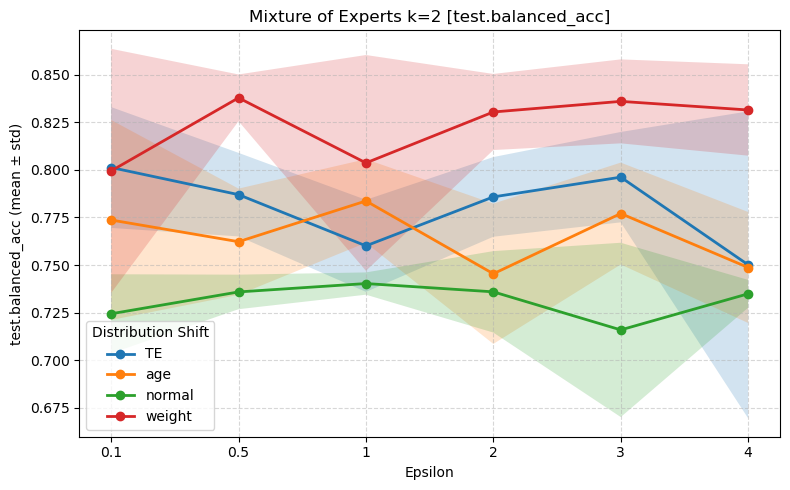

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [45]:
plot_results(path="final_dataset/MoE2", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2")


Shift: TE
MoE.test.weight0 max value: 0.36992016434669495
MoE.test.weight1 max value: 0.3496052443981171
MoE.test.weight2 max value: 0.38456992506980897

Shift: age
MoE.test.weight0 max value: 0.415830959379673
MoE.test.weight1 max value: 0.3917099446058273
MoE.test.weight2 max value: 0.36374593824148177

Shift: normal
MoE.test.weight0 max value: 0.37944889962673184
MoE.test.weight1 max value: 0.3562310367822647
MoE.test.weight2 max value: 0.34507169425487516

Shift: weight
MoE.test.weight0 max value: 0.35935229659080503
MoE.test.weight1 max value: 0.3580274760723114
MoE.test.weight2 max value: 0.38587274253368375


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
4       TE     0.5         0.369920  0.041339         0.326345  0.043275   
0       TE     0.1         0.360120  0.050538         0.349605  0.044544   
20      TE       4         0.328114  0.046634         0.287316  0.031948   
13     age       2         0.415831  0.074426         0.298505  0.098007   
5      age     0.5         0.358886  0.088392         0.391710  0.066010   
21     age       4         0.369303  0.107130         0.266951  0.110651   
14  normal       2         0.379449  0.022905         0.312936  0.056619   
2   normal     0.1         0.331669  0.033948         0.356231  0.039784   
22  normal       4         0.349978  0.013842         0.304950  0.024921   
23  weight       4         0.359352  0.051766         0.329210  0.072156   
19  weight       3         0.301862  0.082452         0.358027  0.058663   
3   weight     0.1         0.304718  0.022995         0.309410  0.042173   

   MoE.test.weight2            
               mean       std  
4          0.303735  0.050318  
0          0.290275  0.031904  
20         0.384570  0.046224  
13         0.285664  0.107836  
5          0.249404  0.101106  
21         0.363746  0.075164  
14         0.307615  0.056104  
2          0.312100  0.050086  
22         0.345072  0.033204  
23         0.311438  0.052475  
19         0.340110  0.060938  
3          0.385873  0.046364

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.360120  0.050538         0.349605  0.044544   
1      age     0.1         0.338958  0.109428         0.349869  0.093106   
2   normal     0.1         0.331669  0.033948         0.356231  0.039784   
3   weight     0.1         0.304718  0.022995         0.309410  0.042173   
4       TE     0.5         0.369920  0.041339         0.326345  0.043275   
5      age     0.5         0.358886  0.088392         0.391710  0.066010   
6   normal     0.5         0.373175  0.064797         0.299968  0.111356   
7   weight     0.5         0.350640  0.058643         0.350888  0.047401   
8       TE       1         0.357539  0.016981         0.327615  0.014344   
9      age       1         0.393248  0.092145         0.345856  0.096977   
10  normal       1         0.335695  0.047860         0.346524  0.042366   
11  weight       1         0.350410  0.030107         0.353019  0.025348   
12      TE       2         0.330770  0.045942         0.322341  0.053240   
13     age       2         0.415831  0.074426         0.298505  0.098007   
14  normal       2         0.379449  0.022905         0.312936  0.056619   
15  weight       2         0.357163  0.055796         0.352148  0.048284   
16      TE       3         0.343171  0.045480         0.289776  0.059274   
17     age       3         0.414327  0.063788         0.329264  0.147558   
18  normal       3         0.362449  0.033253         0.334952  0.062431   
19  weight       3         0.301862  0.082452         0.358027  0.058663   
20      TE       4         0.328114  0.046634         0.287316  0.031948   
21     age       4         0.369303  0.107130         0.266951  0.110651   
22  normal       4         0.349978  0.013842         0.304950  0.024921   
23  weight       4         0.359352  0.051766         0.329210  0.072156   

   MoE.test.weight2            
               mean       std  
0          0.290275  0.031904  
1          0.311173  0.105470  
2          0.312100  0.050086  
3          0.385873  0.046364  
4          0.303735  0.050318  
5          0.249404  0.101106  
6          0.326857  0.076532  
7          0.298472  0.076687  
8          0.314845  0.021540  
9          0.260897  0.104979  
10         0.317781  0.048107  
11         0.296571  0.033676  
12         0.346888  0.050715  
13         0.285664  0.107836  
14         0.307615  0.056104  
15         0.290690  0.046948  
16         0.367053  0.070943  
17         0.256409  0.122693  
18         0.302598  0.075074  
19         0.340110  0.060938  
20         0.384570  0.046224  
21         0.363746  0.075164  
22         0.345072  0.033204  
23         0.311438  0.052475

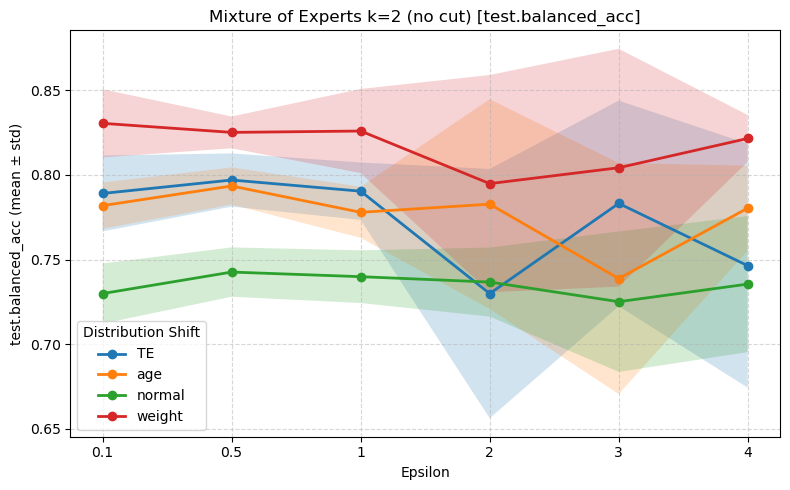

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [46]:
plot_results(path="final_dataset/MoE2-no-cut", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (no cut)")


Shift: TE
MoE.test.weight0 max value: 0.38722435832023616
MoE.test.weight1 max value: 0.32938999235630034
MoE.test.weight2 max value: 0.3427333950996399

Shift: age
MoE.test.weight0 max value: 0.39639570116996764
MoE.test.weight1 max value: 0.35585293471813195
MoE.test.weight2 max value: 0.34354239106178286

Shift: normal
MoE.test.weight0 max value: 0.3949996680021286
MoE.test.weight1 max value: 0.32293170392513276
MoE.test.weight2 max value: 0.3390240788459778

Shift: weight
MoE.test.weight0 max value: 0.3653449207544327
MoE.test.weight1 max value: 0.37266509234905243
MoE.test.weight2 max value: 0.3532276451587677


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
8       TE       1         0.387224  0.006351         0.298105  0.008112   
20      TE       4         0.343654  0.003218         0.329390  0.002254   
0       TE     0.1         0.348834  0.016947         0.308432  0.022186   
9      age       1         0.396396  0.025201         0.340479  0.040864   
13     age       2         0.356728  0.039250         0.355853  0.014664   
21     age       4         0.337729  0.052921         0.318728  0.038778   
18  normal       3         0.395000  0.049270         0.275155  0.053121   
6   normal     0.5         0.350618  0.035751         0.322932  0.037011   
2   normal     0.1         0.345282  0.006618         0.315694  0.031662   
11  weight       1         0.365345  0.005561         0.372665  0.008331   
11  weight       1         0.365345  0.005561         0.372665  0.008331   
15  weight       2         0.342344  0.015422         0.304429  0.035146   

   MoE.test.weight2            
               mean       std  
8          0.314671  0.006245  
20         0.326956  0.003163  
0          0.342733  0.012526  
9          0.263125  0.064205  
13         0.287419  0.042157  
21         0.343542  0.021265  
18         0.329845  0.013240  
6          0.326451  0.019955  
2          0.339024  0.027094  
11         0.261990  0.005940  
11         0.261990  0.005940  
15         0.353228  0.033968

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.348834  0.016947         0.308432  0.022186   
1      age     0.1         0.321641  0.030206         0.346844  0.030809   
2   normal     0.1         0.345282  0.006618         0.315694  0.031662   
3   weight     0.1         0.345596  0.023965         0.305131  0.044555   
4       TE     0.5         0.381279  0.016762         0.310134  0.016970   
5      age     0.5         0.367295  0.018913         0.334502  0.049737   
6   normal     0.5         0.350618  0.035751         0.322932  0.037011   
7   weight     0.5         0.344591  0.006903         0.349329  0.055602   
8       TE       1         0.387224  0.006351         0.298105  0.008112   
9      age       1         0.396396  0.025201         0.340479  0.040864   
10  normal       1         0.377687  0.036201         0.305183  0.022976   
11  weight       1         0.365345  0.005561         0.372665  0.008331   
12      TE       2         0.381283  0.015788         0.295806  0.013390   
13     age       2         0.356728  0.039250         0.355853  0.014664   
14  normal       2         0.388974  0.050795         0.285262  0.039411   
15  weight       2         0.342344  0.015422         0.304429  0.035146   
16      TE       3         0.354717  0.019452         0.320900  0.011606   
17     age       3         0.307203  0.040159         0.351802  0.016341   
18  normal       3         0.395000  0.049270         0.275155  0.053121   
19  weight       3         0.347697  0.018450         0.309238  0.020790   
20      TE       4         0.343654  0.003218         0.329390  0.002254   
21     age       4         0.337729  0.052921         0.318728  0.038778   
22  normal       4         0.348848  0.013500         0.318263  0.018412   
23  weight       4         0.353464  0.018534         0.300368  0.021400   

   MoE.test.weight2            
               mean       std  
0          0.342733  0.012526  
1          0.331515  0.005300  
2          0.339024  0.027094  
3          0.349273  0.037057  
4          0.308586  0.006045  
5          0.298203  0.059185  
6          0.326451  0.019955  
7          0.306080  0.059015  
8          0.314671  0.006245  
9          0.263125  0.064205  
10         0.317130  0.023677  
11         0.261990  0.005940  
12         0.322911  0.017107  
13         0.287419  0.042157  
14         0.325764  0.014833  
15         0.353228  0.033968  
16         0.324383  0.008441  
17         0.340995  0.033662  
18         0.329845  0.013240  
19         0.343065  0.026287  
20         0.326956  0.003163  
21         0.343542  0.021265  
22         0.332889  0.023125  
23         0.346168  0.020920

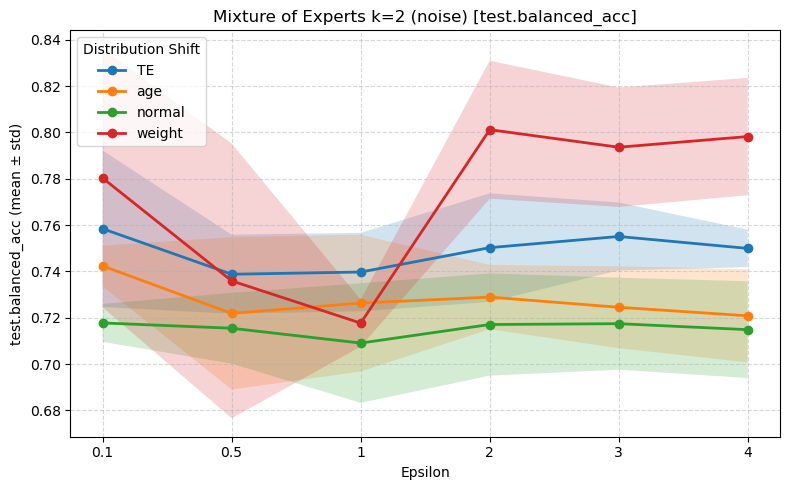

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [47]:
plot_results(path="final_dataset/MoE2-noise", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (noise)")


Shift: TE
MoE.test.weight0 max value: 0.3406361252069473
MoE.test.weight1 max value: 0.32456913888454436
MoE.test.weight2 max value: 0.36981525719165803

Shift: age
MoE.test.weight0 max value: 0.37088770270347593
MoE.test.weight1 max value: 0.33134098351001734
MoE.test.weight2 max value: 0.3323215723037719

Shift: normal
MoE.test.weight0 max value: 0.34576076865196226
MoE.test.weight1 max value: 0.33053183257579805
MoE.test.weight2 max value: 0.34626991450786593

Shift: weight
MoE.test.weight0 max value: 0.35040295124053955
MoE.test.weight1 max value: 0.32571862936019896
MoE.test.weight2 max value: 0.3445115745067596


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
20      TE       4         0.340636  0.008023         0.321251  0.006046   
16      TE       3         0.333799  0.009053         0.324569  0.009777   
0       TE     0.1         0.337588  0.002186         0.292596  0.001505   
17     age       3         0.370888  0.039451         0.320484  0.017025   
21     age       4         0.350039  0.031070         0.331341  0.017151   
5      age     0.5         0.343686  0.007914         0.323993  0.020356   
18  normal       3         0.345761  0.008384         0.321333  0.003960   
6   normal     0.5         0.334288  0.004324         0.330532  0.002548   
22  normal       4         0.329723  0.012175         0.324007  0.013058   
23  weight       4         0.350403  0.006737         0.318359  0.002097   
11  weight       1         0.340872  0.007857         0.325719  0.014627   
7   weight     0.5         0.338335  0.001746         0.317154  0.003288   

   MoE.test.weight2            
               mean       std  
20         0.338112  0.004729  
16         0.341631  0.009106  
0          0.369815  0.002891  
17         0.308628  0.025407  
21         0.318620  0.021097  
5          0.332322  0.024931  
18         0.332907  0.007552  
6          0.335180  0.004709  
22         0.346270  0.009199  
23         0.331238  0.006910  
11         0.333410  0.011565  
7          0.344512  0.004657

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.337588  0.002186         0.292596  0.001505   
1      age     0.1         0.347372  0.011681         0.329613  0.005401   
2   normal     0.1         0.336087  0.003360         0.324085  0.004332   
3   weight     0.1         0.344835  0.006830         0.314483  0.018839   
4       TE     0.5         0.335089  0.001541         0.298028  0.002609   
5      age     0.5         0.343686  0.007914         0.323993  0.020356   
6   normal     0.5         0.334288  0.004324         0.330532  0.002548   
7   weight     0.5         0.338335  0.001746         0.317154  0.003288   
8       TE       1         0.329102  0.004896         0.313061  0.013817   
9      age       1         0.346262  0.009979         0.326038  0.007818   
10  normal       1         0.333432  0.011031         0.329872  0.009117   
11  weight       1         0.340872  0.007857         0.325719  0.014627   
12      TE       2         0.332543  0.006948         0.324137  0.009158   
13     age       2         0.368993  0.032971         0.317673  0.012186   
14  normal       2         0.329258  0.009345         0.328395  0.010621   
15  weight       2         0.345345  0.006472         0.317909  0.003225   
16      TE       3         0.333799  0.009053         0.324569  0.009777   
17     age       3         0.370888  0.039451         0.320484  0.017025   
18  normal       3         0.345761  0.008384         0.321333  0.003960   
19  weight       3         0.344592  0.006003         0.320381  0.002020   
20      TE       4         0.340636  0.008023         0.321251  0.006046   
21     age       4         0.350039  0.031070         0.331341  0.017151   
22  normal       4         0.329723  0.012175         0.324007  0.013058   
23  weight       4         0.350403  0.006737         0.318359  0.002097   

   MoE.test.weight2            
               mean       std  
0          0.369815  0.002891  
1          0.323016  0.012214  
2          0.339828  0.001708  
3          0.340682  0.013214  
4          0.366883  0.001979  
5          0.332322  0.024931  
6          0.335180  0.004709  
7          0.344512  0.004657  
8          0.357837  0.012924  
9          0.327700  0.011711  
10         0.336696  0.003422  
11         0.333410  0.011565  
12         0.343320  0.009144  
13         0.313335  0.026243  
14         0.342347  0.011857  
15         0.336745  0.006844  
16         0.341631  0.009106  
17         0.308628  0.025407  
18         0.332907  0.007552  
19         0.335027  0.007470  
20         0.338112  0.004729  
21         0.318620  0.021097  
22         0.346270  0.009199  
23         0.331238  0.006910

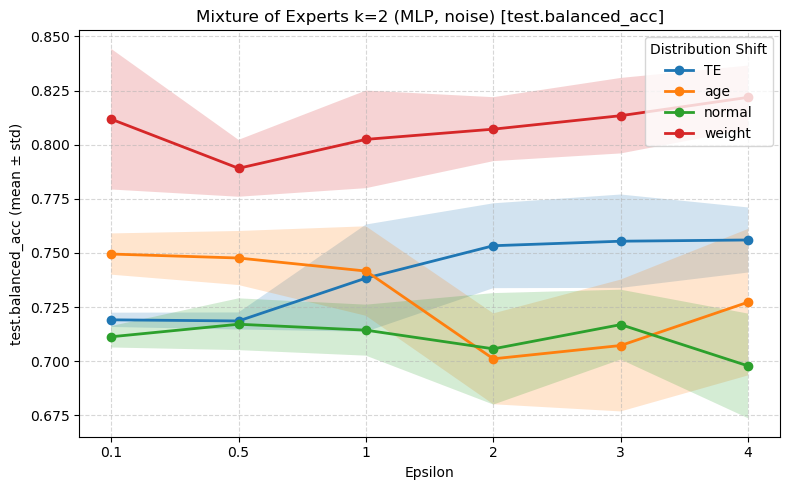

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [48]:
plot_results(path="final_dataset/MoE2-MLP-noise", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (MLP, noise)")


Shift: TE
MoE.test.weight0 max value: 0.35692260861396785
MoE.test.weight1 max value: 0.3503632426261901
MoE.test.weight2 max value: 0.38300697803497313

Shift: age
MoE.test.weight0 max value: 0.3632724851369858
MoE.test.weight1 max value: 0.35422166585922243
MoE.test.weight2 max value: 0.43418772518634796

Shift: normal
MoE.test.weight0 max value: 0.36609475016593934
MoE.test.weight1 max value: 0.39391732811927793
MoE.test.weight2 max value: 0.33672846108675

Shift: weight
MoE.test.weight0 max value: 0.30035521835088724
MoE.test.weight1 max value: 0.37586128413677217
MoE.test.weight2 max value: 0.3733420312404633


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
8       TE       1         0.356923  0.065670         0.260070  0.100907   
20      TE       4         0.313057  0.060709         0.350363  0.039645   
8       TE       1         0.356923  0.065670         0.260070  0.100907   
21     age       4         0.363272  0.071555         0.231672  0.100319   
5      age     0.5         0.230911  0.112474         0.354222  0.090013   
9      age       1         0.274247  0.122686         0.291565  0.124700   
18  normal       3         0.366095  0.088732         0.297177  0.160710   
22  normal       4         0.284472  0.048158         0.393917  0.035502   
18  normal       3         0.366095  0.088732         0.297177  0.160710   
3   weight     0.1         0.300355  0.054971         0.339669  0.046414   
19  weight       3         0.255515  0.077246         0.375861  0.059637   
23  weight       4         0.292448  0.064979         0.334210  0.068878   

   MoE.test.weight2            
               mean       std  
8          0.383007  0.045574  
20         0.336580  0.060193  
8          0.383007  0.045574  
21         0.405055  0.051557  
5          0.414868  0.046855  
9          0.434188  0.067929  
18         0.336728  0.096650  
22         0.321610  0.041630  
18         0.336728  0.096650  
3          0.359976  0.030809  
19         0.368624  0.033860  
23         0.373342  0.030405

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.350569  0.039011         0.295930  0.025591   
1      age     0.1         0.244722  0.101131         0.327267  0.109005   
2   normal     0.1         0.329652  0.035353         0.344229  0.042624   
3   weight     0.1         0.300355  0.054971         0.339669  0.046414   
4       TE     0.5         0.341100  0.039623         0.301915  0.037092   
5      age     0.5         0.230911  0.112474         0.354222  0.090013   
6   normal     0.5         0.348968  0.046290         0.322842  0.054339   
7   weight     0.5         0.299674  0.052921         0.343866  0.037422   
8       TE       1         0.356923  0.065670         0.260070  0.100907   
9      age       1         0.274247  0.122686         0.291565  0.124700   
10  normal       1         0.312349  0.038042         0.374194  0.054451   
11  weight       1         0.297792  0.040880         0.344789  0.050708   
12      TE       2         0.351173  0.079350         0.312085  0.115495   
13     age       2         0.343046  0.082172         0.298753  0.067991   
14  normal       2         0.332151  0.024598         0.375166  0.023786   
15  weight       2         0.273344  0.063622         0.369011  0.042406   
16      TE       3         0.314179  0.023032         0.343911  0.028072   
17     age       3         0.352944  0.067586         0.266344  0.075059   
18  normal       3         0.366095  0.088732         0.297177  0.160710   
19  weight       3         0.255515  0.077246         0.375861  0.059637   
20      TE       4         0.313057  0.060709         0.350363  0.039645   
21     age       4         0.363272  0.071555         0.231672  0.100319   
22  normal       4         0.284472  0.048158         0.393917  0.035502   
23  weight       4         0.292448  0.064979         0.334210  0.068878   

   MoE.test.weight2            
               mean       std  
0          0.353501  0.021113  
1          0.428011  0.048386  
2          0.326118  0.026597  
3          0.359976  0.030809  
4          0.356986  0.039324  
5          0.414868  0.046855  
6          0.328190  0.031788  
7          0.356460  0.024293  
8          0.383007  0.045574  
9          0.434188  0.067929  
10         0.313456  0.046559  
11         0.357419  0.043266  
12         0.336742  0.080507  
13         0.358202  0.092675  
14         0.292683  0.036234  
15         0.357645  0.043020  
16         0.341910  0.023124  
17         0.380712  0.070728  
18         0.336728  0.096650  
19         0.368624  0.033860  
20         0.336580  0.060193  
21         0.405055  0.051557  
22         0.321610  0.041630  
23         0.373342  0.030405

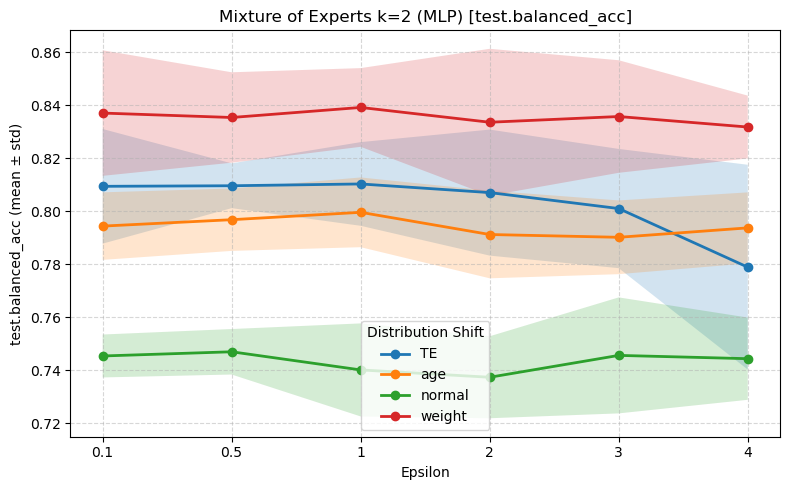

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [49]:
plot_results(path="final_dataset/MoE2-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=2 (MLP)")


Shift: TE
MoE.test.weight0 max value: 0.3350094109773636
MoE.test.weight1 max value: 0.3354301244020462
MoE.test.weight2 max value: 0.3432265162467957

Shift: age
MoE.test.weight0 max value: 0.340798395872116
MoE.test.weight1 max value: 0.3500566840171814
MoE.test.weight2 max value: 0.34240913093090053

Shift: normal
MoE.test.weight0 max value: 0.33734545707702634
MoE.test.weight1 max value: 0.345614355802536
MoE.test.weight2 max value: 0.32707934379577636

Shift: weight
MoE.test.weight0 max value: 0.34312105774879453
MoE.test.weight1 max value: 0.33385967612266537
MoE.test.weight2 max value: 0.36610770225524897


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
16      TE       3         0.335009  0.005712         0.333593  0.004261   
20      TE       4         0.331741  0.004981         0.335430  0.003494   
0       TE     0.1         0.323037  0.006991         0.333737  0.003769   
13     age       2         0.340798  0.011166         0.333455  0.020388   
1      age     0.1         0.326710  0.001387         0.350057  0.001549   
9      age       1         0.338608  0.003410         0.318983  0.002994   
6   normal     0.5         0.337345  0.020198         0.339134  0.016322   
18  normal       3         0.331792  0.012304         0.345614  0.010287   
22  normal       4         0.330316  0.004472         0.342605  0.004736   
19  weight       3         0.343121  0.010043         0.329221  0.007892   
23  weight       4         0.334353  0.010942         0.333860  0.009149   
3   weight     0.1         0.305408  0.014695         0.328485  0.012159   

   MoE.test.weight2            
               mean       std  
16         0.331397  0.006506  
20         0.332828  0.005890  
0          0.343227  0.009418  
13         0.325747  0.021271  
1          0.323234  0.001102  
9          0.342409  0.002472  
6          0.323520  0.009203  
18         0.322593  0.012643  
22         0.327079  0.007964  
19         0.327658  0.009286  
23         0.331788  0.014408  
3          0.366108  0.024003

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.323037  0.006991         0.333737  0.003769   
1      age     0.1         0.326710  0.001387         0.350057  0.001549   
2   normal     0.1         0.336981  0.002776         0.338845  0.004008   
3   weight     0.1         0.305408  0.014695         0.328485  0.012159   
4       TE     0.5         0.334618  0.003565         0.332861  0.002768   
5      age     0.5         0.320504  0.002561         0.344432  0.001871   
6   normal     0.5         0.337345  0.020198         0.339134  0.016322   
7   weight     0.5         0.325366  0.012898         0.323301  0.006695   
8       TE       1         0.332259  0.006669         0.326275  0.007315   
9      age       1         0.338608  0.003410         0.318983  0.002994   
10  normal       1         0.337062  0.009918         0.336063  0.014259   
11  weight       1         0.332046  0.010550         0.327088  0.007745   
12      TE       2         0.332694  0.014068         0.332783  0.011876   
13     age       2         0.340798  0.011166         0.333455  0.020388   
14  normal       2         0.334420  0.009773         0.342464  0.013784   
15  weight       2         0.337260  0.007754         0.330717  0.005764   
16      TE       3         0.335009  0.005712         0.333593  0.004261   
17     age       3         0.326442  0.035050         0.345996  0.026760   
18  normal       3         0.331792  0.012304         0.345614  0.010287   
19  weight       3         0.343121  0.010043         0.329221  0.007892   
20      TE       4         0.331741  0.004981         0.335430  0.003494   
21     age       4         0.334892  0.033280         0.335436  0.024909   
22  normal       4         0.330316  0.004472         0.342605  0.004736   
23  weight       4         0.334353  0.010942         0.333860  0.009149   

   MoE.test.weight2            
               mean       std  
0          0.343227  0.009418  
1          0.323234  0.001102  
2          0.324174  0.003128  
3          0.366108  0.024003  
4          0.332520  0.003451  
5          0.335065  0.002897  
6          0.323520  0.009203  
7          0.351333  0.010860  
8          0.341466  0.009904  
9          0.342409  0.002472  
10         0.326875  0.016981  
11         0.340865  0.008068  
12         0.334522  0.016328  
13         0.325747  0.021271  
14         0.323116  0.010252  
15         0.332023  0.008763  
16         0.331397  0.006506  
17         0.327562  0.015133  
18         0.322593  0.012643  
19         0.327658  0.009286  
20         0.332828  0.005890  
21         0.329672  0.014777  
22         0.327079  0.007964  
23         0.331788  0.014408

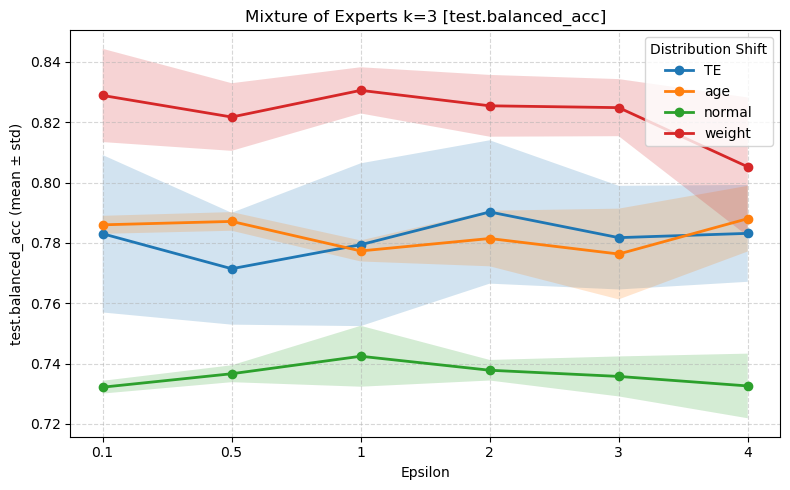

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [50]:
plot_results(path="final_dataset/MoE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3")


Shift: TE
MoE.test.weight0 max value: 0.33713237941265106
MoE.test.weight1 max value: 0.3393940359354019
MoE.test.weight2 max value: 0.332740044593811

Shift: age
MoE.test.weight0 max value: 0.35357524156570436
MoE.test.weight1 max value: 0.32508265674114223
MoE.test.weight2 max value: 0.3602295070886612

Shift: normal
MoE.test.weight0 max value: 0.33460422754287716
MoE.test.weight1 max value: 0.33554149866104127
MoE.test.weight2 max value: 0.3388673275709152

Shift: weight
MoE.test.weight0 max value: 0.33595966696739193
MoE.test.weight1 max value: 0.3333435654640198
MoE.test.weight2 max value: 0.3334838211536407


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
8       TE       1         0.337132  0.004022         0.330990  0.005763   
16      TE       3         0.330369  0.005807         0.339394  0.007214   
12      TE       2         0.334670  0.002928         0.332590  0.004270   
1      age     0.1         0.353575  0.005449         0.309329  0.006881   
17     age       3         0.333229  0.004787         0.325083  0.012342   
9      age       1         0.326537  0.004721         0.313233  0.008748   
10  normal       1         0.334604  0.003726         0.331591  0.004171   
14  normal       2         0.330601  0.002669         0.335541  0.003674   
2   normal     0.1         0.329792  0.003822         0.331341  0.006706   
19  weight       3         0.335960  0.002630         0.332458  0.003446   
3   weight     0.1         0.333750  0.001479         0.333344  0.001428   
23  weight       4         0.334708  0.002969         0.331808  0.003353   

   MoE.test.weight2            
               mean       std  
8          0.331877  0.003279  
16         0.330237  0.004079  
12         0.332740  0.002127  
1          0.337096  0.002312  
17         0.341689  0.010542  
9          0.360230  0.008225  
10         0.333804  0.003389  
14         0.333858  0.003410  
2          0.338867  0.004324  
19         0.331582  0.002491  
3          0.332906  0.001406  
23         0.333484  0.002698

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.336339  0.003361         0.333393  0.006001   
1      age     0.1         0.353575  0.005449         0.309329  0.006881   
2   normal     0.1         0.329792  0.003822         0.331341  0.006706   
3   weight     0.1         0.333750  0.001479         0.333344  0.001428   
4       TE     0.5         0.335984  0.006758         0.334203  0.009659   
5      age     0.5         0.346518  0.003628         0.313728  0.004682   
6   normal     0.5         0.333707  0.004089         0.330050  0.005589   
7   weight     0.5         0.334614  0.002465         0.332901  0.001603   
8       TE       1         0.337132  0.004022         0.330990  0.005763   
9      age       1         0.326537  0.004721         0.313233  0.008748   
10  normal       1         0.334604  0.003726         0.331591  0.004171   
11  weight       1         0.334797  0.001345         0.332699  0.000846   
12      TE       2         0.334670  0.002928         0.332590  0.004270   
13     age       2         0.328793  0.006571         0.315774  0.013326   
14  normal       2         0.330601  0.002669         0.335541  0.003674   
15  weight       2         0.335062  0.002493         0.333069  0.001597   
16      TE       3         0.330369  0.005807         0.339394  0.007214   
17     age       3         0.333229  0.004787         0.325083  0.012342   
18  normal       3         0.331125  0.003549         0.333596  0.003549   
19  weight       3         0.335960  0.002630         0.332458  0.003446   
20      TE       4         0.335654  0.001984         0.331825  0.002116   
21     age       4         0.334384  0.003227         0.324796  0.014984   
22  normal       4         0.332657  0.003438         0.332956  0.003407   
23  weight       4         0.334708  0.002969         0.331808  0.003353   

   MoE.test.weight2            
               mean       std  
0          0.330268  0.003956  
1          0.337096  0.002312  
2          0.338867  0.004324  
3          0.332906  0.001406  
4          0.329812  0.003955  
5          0.339754  0.002214  
6          0.336243  0.005080  
7          0.332485  0.002858  
8          0.331877  0.003279  
9          0.360230  0.008225  
10         0.333804  0.003389  
11         0.332504  0.001233  
12         0.332740  0.002127  
13         0.355433  0.013839  
14         0.333858  0.003410  
15         0.331869  0.002467  
16         0.330237  0.004079  
17         0.341689  0.010542  
18         0.335279  0.003566  
19         0.331582  0.002491  
20         0.332520  0.003380  
21         0.340820  0.012419  
22         0.334387  0.004591  
23         0.333484  0.002698

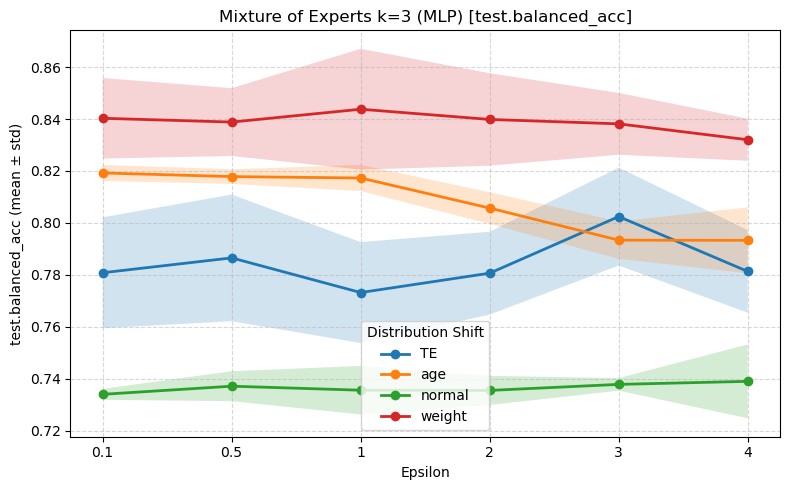

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [51]:
plot_results(path="final_dataset/MoE3-MLP", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (MLP)")


Shift: TE
MoE.test.weight0 max value: 0.3420903027057648
MoE.test.weight1 max value: 0.32086931765079496
MoE.test.weight2 max value: 0.35590782463550563

Shift: age
MoE.test.weight0 max value: 0.3456296741962433
MoE.test.weight1 max value: 0.3333157777786255
MoE.test.weight2 max value: 0.36029046475887294

Shift: normal
MoE.test.weight0 max value: 0.34438041746616366
MoE.test.weight1 max value: 0.3313012093305588
MoE.test.weight2 max value: 0.3380597978830337

Shift: weight
MoE.test.weight0 max value: 0.34114676117897036
MoE.test.weight1 max value: 0.33811006546020506
MoE.test.weight2 max value: 0.34038728773593896


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.342090  0.003930         0.302741  0.012635   
8       TE       1         0.333446  0.002249         0.320869  0.006827   
4       TE     0.5         0.338996  0.002026         0.305096  0.007550   
21     age       4         0.345630  0.005088         0.333316  0.013942   
21     age       4         0.345630  0.005088         0.333316  0.013942   
5      age     0.5         0.337781  0.003294         0.301928  0.016079   
14  normal       2         0.344380  0.000507         0.321476  0.003775   
10  normal       1         0.336433  0.000607         0.331301  0.000758   
18  normal       3         0.331492  0.010702         0.330449  0.011393   
19  weight       3         0.341147  0.005917         0.325184  0.007986   
7   weight     0.5         0.336206  0.001629         0.338110  0.016339   
15  weight       2         0.333479  0.006610         0.326133  0.003883   

   MoE.test.weight2            
               mean       std  
0          0.355168  0.011970  
8          0.345684  0.005293  
4          0.355908  0.005610  
21         0.321055  0.012710  
21         0.321055  0.012710  
5          0.360290  0.019207  
14         0.334143  0.003406  
10         0.332265  0.000363  
18         0.338060  0.006781  
19         0.333670  0.008860  
7          0.325684  0.017950  
15         0.340387  0.007956

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.342090  0.003930         0.302741  0.012635   
1      age     0.1         0.341993  0.001638         0.319992  0.020060   
2   normal     0.1         0.336958  0.000767         0.328358  0.000927   
3   weight     0.1         0.336527  0.003447         0.326834  0.014543   
4       TE     0.5         0.338996  0.002026         0.305096  0.007550   
5      age     0.5         0.337781  0.003294         0.301928  0.016079   
6   normal     0.5         0.337932  0.000802         0.330594  0.000713   
7   weight     0.5         0.336206  0.001629         0.338110  0.016339   
8       TE       1         0.333446  0.002249         0.320869  0.006827   
9      age       1         0.343710  0.012986         0.305802  0.019068   
10  normal       1         0.336433  0.000607         0.331301  0.000758   
11  weight       1         0.335355  0.003572         0.331237  0.012446   
12      TE       2         0.331960  0.002971         0.320378  0.007243   
13     age       2         0.343875  0.020445         0.322109  0.010636   
14  normal       2         0.344380  0.000507         0.321476  0.003775   
15  weight       2         0.333479  0.006610         0.326133  0.003883   
16      TE       3         0.332945  0.001538         0.317755  0.002617   
17     age       3         0.332713  0.007945         0.332162  0.007318   
18  normal       3         0.331492  0.010702         0.330449  0.011393   
19  weight       3         0.341147  0.005917         0.325184  0.007986   
20      TE       4         0.334862  0.004104         0.319309  0.006376   
21     age       4         0.345630  0.005088         0.333316  0.013942   
22  normal       4         0.337145  0.011818         0.325920  0.008836   
23  weight       4         0.340081  0.003080         0.325909  0.001967   

   MoE.test.weight2            
               mean       std  
0          0.355168  0.011970  
1          0.338015  0.021466  
2          0.334683  0.000619  
3          0.336640  0.015342  
4          0.355908  0.005610  
5          0.360290  0.019207  
6          0.331474  0.000431  
7          0.325684  0.017950  
8          0.345684  0.005293  
9          0.350488  0.013472  
10         0.332265  0.000363  
11         0.333408  0.013531  
12         0.347662  0.004590  
13         0.334016  0.014943  
14         0.334143  0.003406  
15         0.340387  0.007956  
16         0.349300  0.001333  
17         0.335125  0.010337  
18         0.338060  0.006781  
19         0.333670  0.008860  
20         0.345829  0.010382  
21         0.321055  0.012710  
22         0.336936  0.010149  
23         0.334010  0.004673

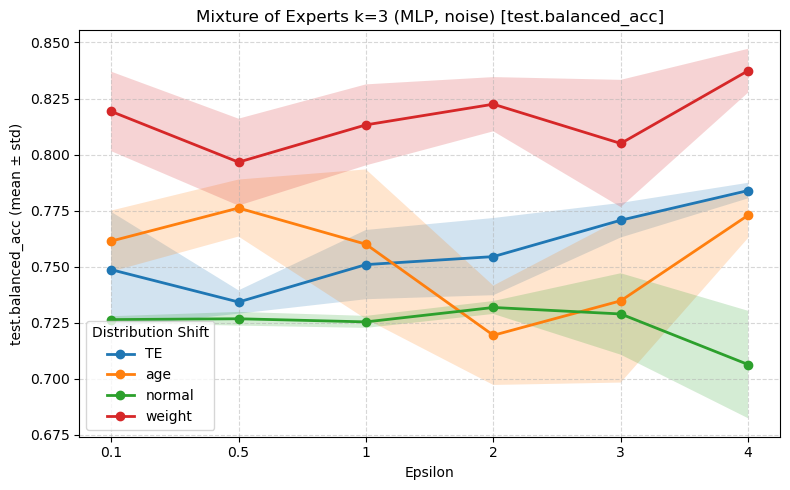

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [52]:
plot_results(path="final_dataset/MoE3-MLP-noise", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=3 (MLP, noise)")

### Switch Transformer

In [53]:
metric

['test.balanced_acc']


Shift: TE
MoE.test.weight0 max value: 0.408266669511795
MoE.test.weight1 max value: 0.020533334091305706
MoE.test.weight2 max value: 0.5903999924659729

Shift: age
MoE.test.weight0 max value: 0.855733323097229
MoE.test.weight1 max value: 0.13653333336114878
MoE.test.weight2 max value: 0.12746666474267837

Shift: normal
MoE.test.weight0 max value: 0.3240000009536743
MoE.test.weight1 max value: 0.11706666816025968
MoE.test.weight2 max value: 0.5893333256244659

Shift: weight
MoE.test.weight0 max value: 0.9986666738986969
MoE.test.weight1 max value: 0.02346666678786277
MoE.test.weight2 max value: 0.0015999999828636598


Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.408267  0.005822         0.008533  0.004131   
16      TE       3         0.400533  0.017545         0.020533  0.036930   
4       TE     0.5         0.402933  0.007161         0.006667  0.002880   
5      age     0.5         0.855733  0.037003         0.104800  0.038047   
13     age       2         0.809067  0.057828         0.136533  0.049679   
17     age       3         0.738933  0.230993         0.133600  0.104696   
6   normal     0.5         0.324000  0.002266         0.111467  0.015791   
22  normal       4         0.320533  0.005152         0.117067  0.037972   
10  normal       1         0.322133  0.005594         0.088533  0.020184   
7   weight     0.5         0.998667  0.001886         0.000000  0.000000   
11  weight       1         0.975200  0.060927         0.023467  0.061453   
15  weight       2         0.984800  0.027913         0.013600  0.028678   

   MoE.test.weight2            
               mean       std  
0          0.583200  0.007955  
16         0.578933  0.022327  
4          0.590400  0.007458  
5          0.039467  0.058637  
13         0.054400  0.063792  
17         0.127467  0.156595  
6          0.564533  0.015296  
22         0.562400  0.040568  
10         0.589333  0.021918  
7          0.001333  0.001886  
11         0.001333  0.002266  
15         0.001600  0.002249

Shift epsilon MoE.test.weight0           MoE.test.weight1            \
                               mean       std             mean       std   
0       TE     0.1         0.408267  0.005822         0.008533  0.004131   
1      age     0.1         0.825867  0.062223         0.105067  0.036525   
2   normal     0.1         0.323200  0.002754         0.101867  0.022898   
3   weight     0.1         0.985333  0.023391         0.013333  0.024115   
4       TE     0.5         0.402933  0.007161         0.006667  0.002880   
5      age     0.5         0.855733  0.037003         0.104800  0.038047   
6   normal     0.5         0.324000  0.002266         0.111467  0.015791   
7   weight     0.5         0.998667  0.001886         0.000000  0.000000   
8       TE       1         0.406400  0.006676         0.009333  0.006061   
9      age       1         0.757067  0.160982         0.134400  0.039657   
10  normal       1         0.322133  0.005594         0.088533  0.020184   
11  weight       1         0.975200  0.060927         0.023467  0.061453   
12      TE       2         0.402933  0.004254         0.011733  0.004391   
13     age       2         0.809067  0.057828         0.136533  0.049679   
14  normal       2         0.321600  0.006310         0.103467  0.042477   
15  weight       2         0.984800  0.027913         0.013600  0.028678   
16      TE       3         0.400533  0.017545         0.020533  0.036930   
17     age       3         0.738933  0.230993         0.133600  0.104696   
18  normal       3         0.324000  0.006914         0.091200  0.039709   
19  weight       3         0.985867  0.040986         0.013067  0.041320   
20      TE       4         0.405867  0.006862         0.008267  0.004064   
21     age       4         0.811733  0.051528         0.108267  0.047789   
22  normal       4         0.320533  0.005152         0.117067  0.037972   
23  weight       4         0.985067  0.029700         0.013867  0.030191   

   MoE.test.weight2            
               mean       std  
0          0.583200  0.007955  
1          0.069067  0.085513  
2          0.574933  0.024479  
3          0.001333  0.002266  
4          0.590400  0.007458  
5          0.039467  0.058637  
6          0.564533  0.015296  
7          0.001333  0.001886  
8          0.584267  0.006465  
9          0.108533  0.138427  
10         0.589333  0.021918  
11         0.001333  0.002266  
12         0.585333  0.006681  
13         0.054400  0.063792  
14         0.574933  0.041028  
15         0.001600  0.002249  
16         0.578933  0.022327  
17         0.127467  0.156595  
18         0.584800  0.034725  
19         0.001067  0.001865  
20         0.585867  0.008248  
21         0.080000  0.062006  
22         0.562400  0.040568  
23         0.001067  0.001865

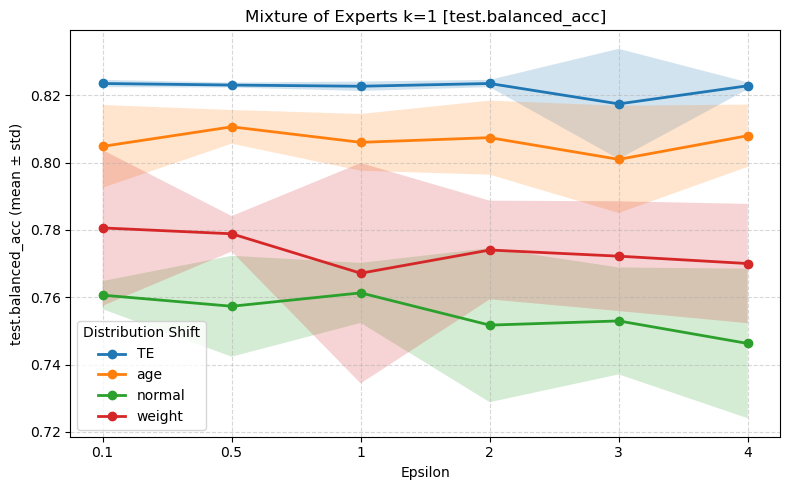

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [54]:
plot_results(path="final_dataset/MoE1", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts k=1")


Shift: TE
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: age
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: normal
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408

Shift: weight
MoE.test.weight0 max value: 0.3333333432674408
MoE.test.weight1 max value: 0.3333333432674408
MoE.test.weight2 max value: 0.3333333432674408


Shift epsilon MoE.test.weight0      MoE.test.weight1       \
                               mean  std             mean  std   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   

   MoE.test.weight2       
               mean  std  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
0          0.333333  0.0  
4          0.333333  0.0  
8          0.333333  0.0  
12         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
1          0.333333  0.0  
5          0.333333  0.0  
9          0.333333  0.0  
13         0.333333  0.0  
2 

Shift epsilon MoE.test.weight0      MoE.test.weight1       \
                               mean  std             mean  std   
0       TE   0.001         0.333333  0.0         0.333333  0.0   
1      age   0.001         0.333333  0.0         0.333333  0.0   
2   normal   0.001         0.333333  0.0         0.333333  0.0   
3   weight   0.001         0.333333  0.0         0.333333  0.0   
4       TE    0.01         0.333333  0.0         0.333333  0.0   
5      age    0.01         0.333333  0.0         0.333333  0.0   
6   normal    0.01         0.333333  0.0         0.333333  0.0   
7   weight    0.01         0.333333  0.0         0.333333  0.0   
8       TE     0.1         0.333333  0.0         0.333333  0.0   
9      age     0.1         0.333333  0.0         0.333333  0.0   
10  normal     0.1         0.333333  0.0         0.333333  0.0   
11  weight     0.1         0.333333  0.0         0.333333  0.0   
12      TE       2         0.333333  0.0         0.333333  0.0   
13     age       2         0.333333  0.0         0.333333  0.0   
14  normal       2         0.333333  0.0         0.333333  0.0   
15  weight       2         0.333333  0.0         0.333333  0.0   

   MoE.test.weight2       
               mean  std  
0          0.333333  0.0  
1          0.333333  0.0  
2          0.333333  0.0  
3          0.333333  0.0  
4          0.333333  0.0  
5          0.333333  0.0  
6          0.333333  0.0  
7          0.333333  0.0  
8          0.333333  0.0  
9          0.333333  0.0  
10         0.333333  0.0  
11         0.333333  0.0  
12         0.333333  0.0  
13         0.333333  0.0  
14         0.333333  0.0  
15         0.333333  0.0

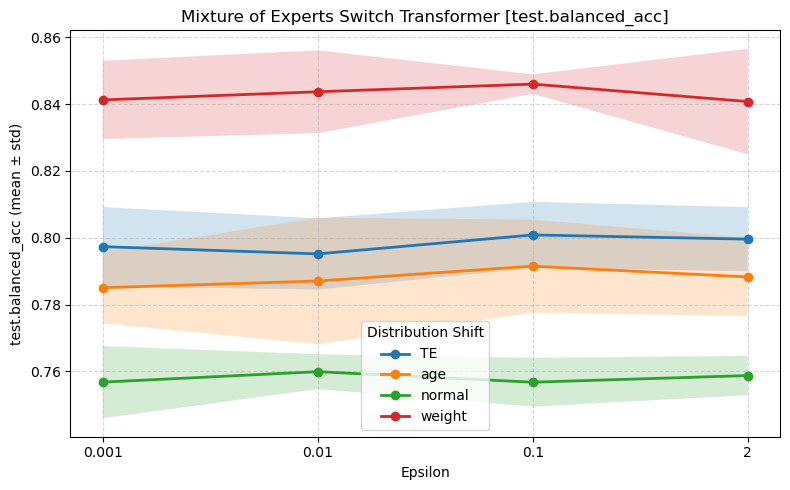

test.acc           test.balanced_acc          
            mean       std              mean       std
Shift                                                 
TE      0.854933  0.004391          0.818236  0.010816
age     0.833067  0.001865          0.829321  0.002959
normal  0.837600  0.001514          0.752576  0.004230
weight  0.858133  0.003511          0.852770  0.004061

In [55]:
plot_results(path="final_dataset/MoE1-Switch-NumE3", group_col="epsilon", filename="test", exp_name="MoE", second_group_col="Shift", metric=metric, title="Mixture of Experts Switch Transformer")